<a href="https://colab.research.google.com/github/Aarthisankar20/Codealpha-tasks/blob/main/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/Unemployment in India.csv")
df_2020 = pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df_2020.columns = df_2020.columns.str.strip()
df_2020['Date'] = pd.to_datetime(df_2020['Date'])
df_2020['Year'] = df_2020['Date'].dt.year

covid_avg = df_2020.groupby('Year')['Estimated Unemployment Rate (%)'].mean()
print(covid_avg)

Year
2020    12.236929
Name: Estimated Unemployment Rate (%), dtype: float64


/tmp/ipython-input-3270214004.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_2020['Date'] = pd.to_datetime(df_2020['Date'])


In [6]:
print(df.info())
print(df.isnull().sum())

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated 

/tmp/ipython-input-569237228.py:8: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

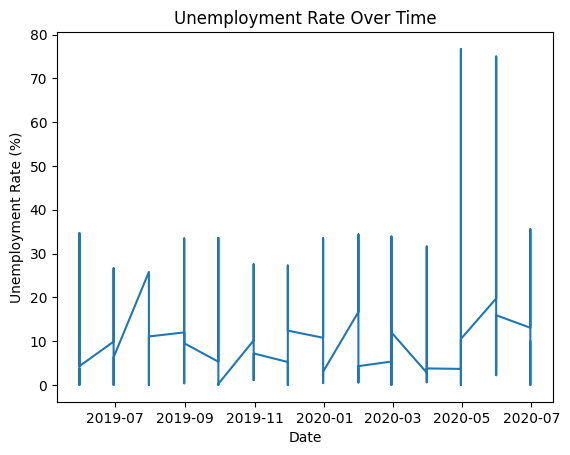

In [8]:
plt.figure()
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time")
plt.show()

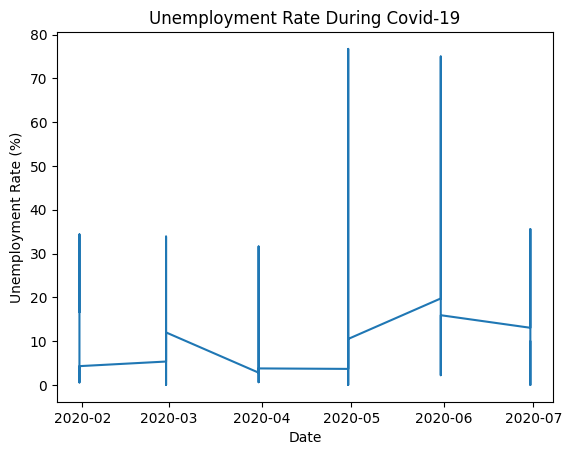

In [9]:
covid_data = df[df['Date'].dt.year >= 2020]

plt.figure()
plt.plot(covid_data['Date'], covid_data['Estimated Unemployment Rate (%)'])
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate During Covid-19")
plt.show()

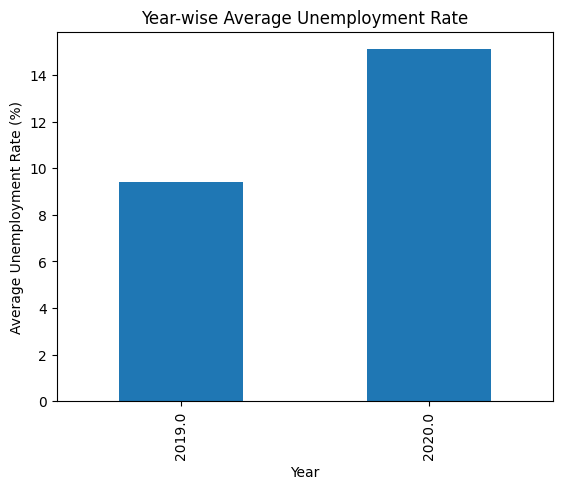

In [10]:
df['Year'] = df['Date'].dt.year

yearly_avg = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

plt.figure()
yearly_avg.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Year-wise Average Unemployment Rate")
plt.show()

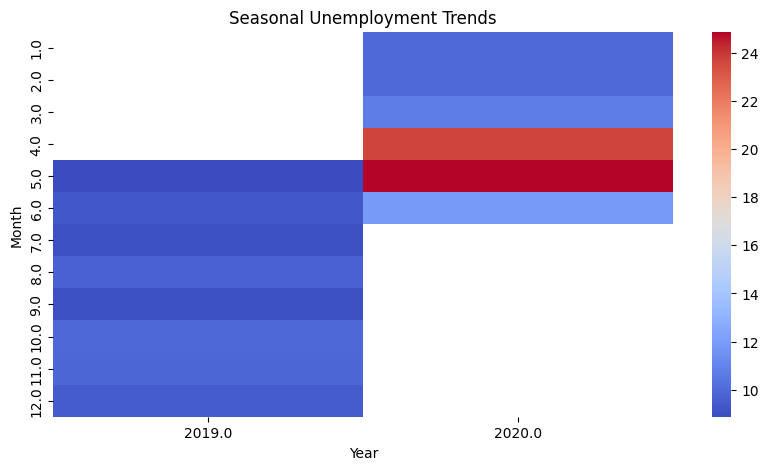

In [11]:
df['Month'] = df['Date'].dt.month
pivot = df.pivot_table(values='Estimated Unemployment Rate (%)', index='Month', columns='Year')

plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Seasonal Unemployment Trends")
plt.show()